In [2]:
include("BarrierSynthesis.jl")
# include("PlotBarriers.jl")

compute_next_level_barriersPM (generic function with 1 method)

In [3]:
@polyvar u[1:1]
@polyvar(x[1:4]) # x[1] is x, x[2] is y, x[3] is θ, x[4] is error
v = 5
    dynamics = [
        (ctrl -> [v*(2.0/π)*(x[3] + π/2.0)-0.2x[4],v*(-2.0/π)*(x[3]+π)-0.2x[4], ctrl[1], 0.]),
        (ctrl -> [v*(2.0/π)*(x[3] + π/2.0)-0.2x[4],v*(2.0/π)*x[3]+0.2x[4], ctrl[1], 0]),
        (ctrl -> [v*(-2.0/π)*(x[3] - π/2.0)+0.2x[4],v*(2.0/π)*x[3]+0.2x[4], ctrl[1], 0]),
        (ctrl -> [v*(-2.0/π)*(x[3] - π/2.0)+0.2x[4],v*(-2.0/π)*(x[3]-π)-0.2x[4], ctrl[1], 0]),
    ]
g = 1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin
bounds = [[-10., 10.], [-10., 10.], [-π,π], [-1.,1.]]

4-element Vector{Vector{Float64}}:
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-3.141592653589793, 3.141592653589793]
 [-1.0, 1.0]

In [4]:
λ = 1
ϵ = 1
max_degree=4
U = [[-10.], [10.]]
n_tests = 100

100

In [5]:
test_pts = [ get_random(bounds, g) for _ in 1:n_tests]

100-element Vector{Vector{Float64}}:
 [-9.917781348135685, 9.79081957419346, -2.943607320038938, -0.02643490537621518]
 [0.664767647635891, -9.110062667926154, -2.3427611404764574, 0.4302030064852007]
 [-6.484639506747907, -8.695565696542948, 0.4915874770048201, -0.41024319413300403]
 [-9.667515586308735, -2.647254900120897, 3.02681264274199, -0.24523012353032314]
 [-1.2394335455140055, -1.2797425366122752, 0.21935322292566006, 0.5886236768740178]
 [-4.624955640916428, 8.276591321437078, 2.9740851142237883, -0.7770573271972483]
 [-7.537336240418114, -6.836930126484038, 1.1642701173667795, 0.26041471771586644]
 [-4.289975463231281, 3.9713320951005375, 2.7121424452663083, 0.20643459658939411]
 [-5.874925440788505, -2.510283143132959, -1.2685404765687844, -0.3793619757045834]
 [2.1079282490450026, 4.8440603345300755, 0.7359165570114659, -0.9249927763394152]
 [-9.104497373502031, -1.126028327390319, 1.1209204390581995, 0.7677740094882886]
 [6.145091406820214, 6.227726292084505, -2.17030124

In [6]:
function findRepulsiveBarrier_HybridDB(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4,ϵ = 1.,τ = .1, γ = 10.)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set( (var-lb)*(ub-var) >= 0)
        return dom
    end
    # solver = optimizer_with_attributes(CSDP.Optimizer)
    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver);
    monos = monomials(x, 0:max_degree)
    N = length(monos) 
    @variable(model, -γ <= c[1:N] <= γ)
#     @variable(model, κ >= 0)
    B = polynomial(c[1:end], monos)
    dom_list = prepare_domain(x, bounds)
    dom = reduce( (s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $dom")

    @constraint(model, cons1, B <= -ϵ, domain = dom ∩ @set(g >= 0))

    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[3], (i-3) * π/2, (i-2) * π/2)
        # @constraint(model, dBdt >= (log(2)/τ) * B, domain = dom ∩ dom_i)
        @constraint(model, dBdt >= (log(2)/τ) * B, domain = dom ∩ dom_i)
    end

    set_objective_sense(model, MOI.FEASIBILITY_SENSE)
    objective_fn = sum([B(pt...) for pt in test_pts])
    @objective(model, Max, objective_fn) # keep as many points outside the barrier as you can
    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")
    if stat != FEASIBLE_POINT
        return missing
    end
    return value(B)
end

findRepulsiveBarrier_HybridDB (generic function with 1 method)

In [7]:

function compute_recenter_K(B, x, bounds; α=0.25, γK=1e3)
    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)

    # shift variables q = (q1,q2)
    @polyvar q1 q2
    q = [q1, q2]

    # state domain D
    dom_list = prepare_domain(x, bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)

    # shift domain Qα
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)

    # shifted barrier B(x - E q)
    # translation only affects first two coordinates
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    ΔB = B_shift - B

    # decision variable K
    @variable(model, 0 <= K <= γK)

    # Require K >= ΔB on D × Qα
    @constraint(model, K >= ΔB, domain = D ∩ Qα)

    @objective(model, Min, K)
    optimize!(model)

    stat = termination_status(model)
    pstat = primal_status(model)
    println("termination = ", stat)
    println("primal status = ", pstat)

    if pstat != MOI.FEASIBLE_POINT
        error("Failed to certify K")
    end

    return value(K), ΔB
end

compute_recenter_K (generic function with 1 method)

In [8]:
B_1= findRepulsiveBarrier_HybridDB(x,U[1],g,dynamics,test_pts)
display(B_1)
K_1 = compute_recenter_K(B_1, x, bounds)
display(K_1) 
test_pts = filter!(pt -> B_1(pt...) <= 0., test_pts)

Domain: { (x[1], x[2], x[3], x[4]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 3.141592653589793 + x[3] ≥ 0, 3.141592653589793 - x[3] ≥ 0, 9.869604401089358 - x[3]^2 ≥ 0, 1.0 + x[4] ≥ 0, 1.0 - x[4] ≥ 0, 1.0 - x[4]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : maximize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 350             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 70              
  Matrix variables       : 42 (scalarized: 1155)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1            

-9.999999950770635 + 8.836173445612422x₄ + 3.3256403264601766x₃ - 0.9142663049696973x₂ + 1.3413767941431534x₁ - 7.6034773678832055x₄² - 9.99999973800343x₃x₄ - 8.706592139152521x₃² - 0.6596508261366455x₂x₄ + 0.9138351545671966x₂x₃ + 0.9601956565710347x₂² - 0.15288866771933216x₁x₄ - 1.9370269902235635x₁x₃ + 0.0904816764165599x₁x₂ + 0.3071801721652809x₁² + 0.8767351527905667x₄³ + 1.5069794198613051x₃x₄² - 0.02896421660359887x₃²x₄ - 2.4081245557484894x₃³ + 0.3169026299419678x₂x₄² + 0.24989548004622011x₂x₃x₄ + 0.387477702133481x₂x₃² - 0.5053293400883327x₂²x₄ - 0.6354754910027629x₂²x₃ - 0.007281971801172109x₂³ - 1.3272404112298977x₁x₄² - 1.695599701698681x₁x₃x₄ - 0.476506109811239x₁x₃² + 0.006032434482679578x₁x₂x₄ - 0.10889363975757664x₁x₂x₃ - 0.1280469704100363x₁x₂² - 0.7641673026369721x₁²x₄ - 0.44795995328990945x₁²x₃ - 0.017228032158071515x₁²x₂ - 0.09409806505857382x₁³ - 0.19665138269278684x₄⁴ - 0.11736777024780769x₃x₄³ - 0.3835082744989786x₃²x₄² + 0.8675582950201665x₃³x₄ + 0.2061363569278

Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 210             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 1               
  Matrix variables       : 14 (scalarized: 770)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes              : 1               
Lin. dep.  - dual attempts          : 0       

(59.0606785158365, 0.9142663049696973q2 - 1.3413767941431534q1 + 0.9601956565710347q2² + 0.0904816764165599q1q2 + 0.3071801721652809q1² + 0.6596508261366455x₄q2 + 0.15288866771933216x₄q1 - 0.9138351545671966x₃q2 + 1.9370269902235635x₃q1 - 1.9203913131420693x₂q2 - 0.0904816764165599x₂q1 - 0.0904816764165599x₁q2 - 0.6143603443305617x₁q1 + 0.007281971801172109q2³ + 0.1280469704100363q1q2² + 0.017228032158071515q1²q2 + 0.09409806505857382q1³ - 0.5053293400883327x₄q2² + 0.006032434482679578x₄q1q2 - 0.7641673026369721x₄q1² - 0.3169026299419678x₄²q2 + 1.3272404112298977x₄²q1 - 0.6354754910027629x₃q2² - 0.10889363975757664x₃q1q2 - 0.44795995328990945x₃q1² - 0.24989548004622011x₃x₄q2 + 1.695599701698681x₃x₄q1 - 0.387477702133481x₃²q2 + 0.476506109811239x₃²q1 - 0.021845915403516325x₂q2² - 0.2560939408200726x₂q1q2 - 0.017228032158071515x₂q1² + 1.0106586801766655x₂x₄q2 - 0.006032434482679578x₂x₄q1 + 1.2709509820055258x₂x₃q2 + 0.10889363975757664x₂x₃q1 + 0.021845915403516325x₂²q2 + 0.12804697041003

58-element Vector{Vector{Float64}}:
 [-6.484639506747907, -8.695565696542948, 0.4915874770048201, -0.41024319413300403]
 [-9.667515586308735, -2.647254900120897, 3.02681264274199, -0.24523012353032314]
 [-1.2394335455140055, -1.2797425366122752, 0.21935322292566006, 0.5886236768740178]
 [-4.624955640916428, 8.276591321437078, 2.9740851142237883, -0.7770573271972483]
 [-7.537336240418114, -6.836930126484038, 1.1642701173667795, 0.26041471771586644]
 [-4.289975463231281, 3.9713320951005375, 2.7121424452663083, 0.20643459658939411]
 [2.1079282490450026, 4.8440603345300755, 0.7359165570114659, -0.9249927763394152]
 [-9.104497373502031, -1.126028327390319, 1.1209204390581995, 0.7677740094882886]
 [1.0700909735467423, -2.4916532284977766, -1.979654195578874, -0.024407077861929194]
 [2.8080658605726434, 8.516967343379687, 2.7624558337964027, -0.8577035575152694]
 [0.05489408646618443, -4.941441171211832, 1.9341169576836892, 0.47153502148913295]
 [8.782921864279444, -8.586026438820094, 2.70724

In [9]:
B_2 = findRepulsiveBarrier_HybridDB(x,U[2],g,dynamics, test_pts)
display(B_2)
K_2 = compute_recenter_K(B_2, x, bounds)
display(K_2) 
test_pts = filter!(pt -> B_2(pt...) <= 0., test_pts)

Domain: { (x[1], x[2], x[3], x[4]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 3.141592653589793 + x[3] ≥ 0, 3.141592653589793 - x[3] ≥ 0, 9.869604401089358 - x[3]^2 ≥ 0, 1.0 + x[4] ≥ 0, 1.0 - x[4] ≥ 0, 1.0 - x[4]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : maximize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 350             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 70              
  Matrix variables       : 42 (scalarized: 1155)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1            

-9.999999933981092 + 0.8853956404066704x₄ + 2.587245361931713x₃ + 2.4982548291279856x₂ + 0.9838931191293385x₁ - 9.999998620243952x₄² + 9.999998761066939x₃x₄ - 8.012268104796279x₃² - 0.2020138739083135x₂x₄ + 7.9871492791944885x₂x₃ - 9.99999989622108x₂² + 9.999999408303646x₁x₄ - 9.200468951853408x₁x₃ + 9.999999831613893x₁x₂ - 9.99999967586263x₁² + 0.04707654909511363x₄³ + 6.136550293265644x₃x₄² - 3.9610533141645377x₃²x₄ + 0.5716441911163277x₃³ + 0.23299372460095x₂x₄² - 0.5026734509262961x₂x₃x₄ - 1.125138811977491x₂x₃² + 0.21959448055034356x₂²x₄ + 5.586726079101305x₂²x₃ - 0.018695808300280815x₂³ + 1.739995540672974x₁x₄² + 0.6764812438131776x₁x₃x₄ - 0.32614342893410314x₁x₃² + 0.075366557346815x₁x₂x₄ - 4.775797126574059x₁x₂x₃ - 0.008792374675633327x₁x₂² + 0.5363955716452018x₁²x₄ + 6.173297458554413x₁²x₃ - 0.03417777424027475x₁²x₂ + 0.013147386723973621x₁³ - 1.223220853826406x₄⁴ - 0.4603273830572096x₃x₄³ - 1.4305666693488361x₃²x₄² + 0.24655052555616197x₃³x₄ + 0.23985770629672817x₃⁴ + 0.02227

Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 210             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 1               
  Matrix variables       : 14 (scalarized: 770)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes              : 1               
Lin. dep.  - dual attempts          : 0       

(274.7450647370765, -2.4982548291279856q2 - 0.9838931191293385q1 - 9.99999989622108q2² + 9.999999831613893q1q2 - 9.99999967586263q1² + 0.2020138739083135x₄q2 - 9.999999408303646x₄q1 - 7.9871492791944885x₃q2 + 9.200468951853408x₃q1 + 19.99999979244216x₂q2 - 9.999999831613893x₂q1 - 9.999999831613893x₁q2 + 19.99999935172526x₁q1 + 0.018695808300280815q2³ + 0.008792374675633327q1q2² + 0.03417777424027475q1²q2 - 0.013147386723973621q1³ + 0.21959448055034356x₄q2² + 0.075366557346815x₄q1q2 + 0.5363955716452018x₄q1² - 0.23299372460095x₄²q2 - 1.739995540672974x₄²q1 + 5.586726079101305x₃q2² - 4.775797126574059x₃q1q2 + 6.173297458554413x₃q1² + 0.5026734509262961x₃x₄q2 - 0.6764812438131776x₃x₄q1 + 1.125138811977491x₃²q2 + 0.32614342893410314x₃²q1 - 0.056087424900842446x₂q2² - 0.017584749351266655x₂q1q2 - 0.03417777424027475x₂q1² - 0.4391889611006871x₂x₄q2 - 0.075366557346815x₂x₄q1 - 11.17345215820261x₂x₃q2 + 4.775797126574059x₂x₃q1 + 0.056087424900842446x₂²q2 + 0.008792374675633327x₂²q1 - 0.0087923

27-element Vector{Vector{Float64}}:
 [-6.484639506747907, -8.695565696542948, 0.4915874770048201, -0.41024319413300403]
 [-1.2394335455140055, -1.2797425366122752, 0.21935322292566006, 0.5886236768740178]
 [-7.537336240418114, -6.836930126484038, 1.1642701173667795, 0.26041471771586644]
 [2.1079282490450026, 4.8440603345300755, 0.7359165570114659, -0.9249927763394152]
 [-9.104497373502031, -1.126028327390319, 1.1209204390581995, 0.7677740094882886]
 [1.0700909735467423, -2.4916532284977766, -1.979654195578874, -0.024407077861929194]
 [9.592690690011047, 1.2037008924900956, 0.41897393788044557, -0.4861525316950823]
 [5.7890008635330545, 9.590128954638182, -1.4958281585372268, 0.4540565009496724]
 [8.476682726784489, -2.000053730207199, -1.8660208049874543, 0.3053346143854765]
 [7.7244761350523845, 8.376774991320382, -1.5183755155954846, -0.6143450562433719]
 [7.946610749521607, -2.187792407256226, -1.0108588233220543, -0.8642072708122135]
 [8.188355818507397, -4.899244730548475, 0.37557

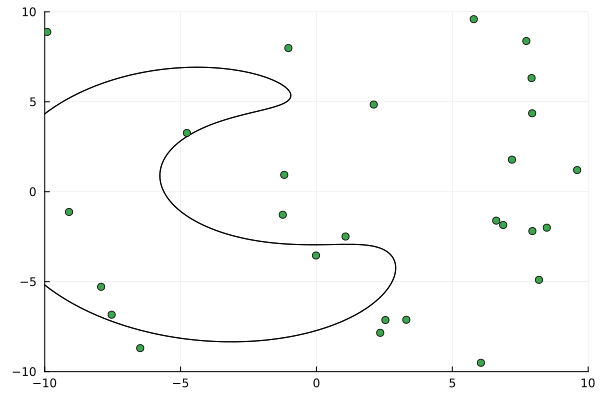

In [10]:
using Plots

function make_contour_plot(B::Polynomial, limits ::Tuple{Float64,Float64}, clr::String; x3_val=0.0,x4_val=0.0)
    x = range(limits[1], limits[2], length=500)
    y = range(limits[1], limits[2], length=500)
    my_fun(xa::Float64,ya::Float64) = B([xa, ya, x3_val, x4_val])
    z = @.my_fun(x', y)
    contour!(x, y, z,levels=[0.0, 0.0], color=clr, colorbar=false)
end

limits=(-10., 10.)
plot(xlims = limits, ylims = limits)
# make_contour_plot(g, limits,"red") 
make_contour_plot(B_1, limits, "black")
make_contour_plot(B_2, limits, "blue")

plot!([x1 for (x1,_) in test_pts], [x2 for (_, x2) in test_pts], seriestype=:scatter, labels=false)


In [11]:
using LaTeXStrings
function circleShape(x,y, r)
    θ = LinRange(0, 2*π, 500)
    x .+ r*cos.(θ), y .+ r*sin.(θ)
end
function plot_ics_region(limits::Tuple{Float64,Float64}, all_barriers::Vector{<:Polynomial}; δ = 0.5, x3_val=π/2,x4_val=0.)
    plot(xlims=limits, ylims=limits)
    rectangle(w, h, x, y) = Shape(x .+ [0,w,w,0], y .+ [0,0,h,h])
    for x in limits[1]:δ:limits[2]
        for y in limits[1]:δ:limits[2]
           if (any([ B(x, y, x3_val, x4_val) >= 0. for B in all_barriers]))
              plot!(rectangle(δ, δ, x-δ, y-δ), label=false, fill=:green, opacity=0.5,linecolor=:green)
           end
        end
    end
    plot!(circleShape(0,0,1.), seriestype =[:shape], lw=0.5, c=:black, linecolor=:black, legend=false, aspectratio=1  )
    plot!(xlims=limits, ylims=limits)
end

plot_ics_region (generic function with 1 method)

In [12]:
all_barriers = [B_1, B_2]

2-element Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}:
 -9.999999950770635 + 8.836173445612422x₄ + 3.3256403264601766x₃ - 0.9142663049696973x₂ + 1.3413767941431534x₁ - 7.6034773678832055x₄² - 9.99999973800343x₃x₄ - 8.706592139152521x₃² - 0.6596508261366455x₂x₄ + 0.9138351545671966x₂x₃ + 0.9601956565710347x₂² - 0.15288866771933216x₁x₄ - 1.9370269902235635x₁x₃ + 0.0904816764165599x₁x₂ + 0.3071801721652809x₁² + 0.8767351527905667x₄³ + 1.5069794198613051x₃x₄² - 0.02896421660359887x₃²x₄ - 2.4081245557484894x₃³ + 0.3169026299419678x₂x₄² + 0.24989548004622011x₂x₃x₄ + 0.387477702133481x₂x₃² - 0.5053293400883327x₂²x₄ - 0.6354754910027629x₂²x₃ - 0.007281971801172109x₂³ - 1.3272404112298977x₁x₄² - 1.695599701698681x₁x₃x₄ - 0.476506109811239x₁x₃² + 0.006032434482679578x₁x₂x₄ - 0.10889363975757664x₁x₂x₃ - 0.1280469704100363x₁x₂² - 0.7641673026369721x₁²x₄ - 0.44795995328990945x₁²x₃ - 0.017228032158071515x₁²x₂ - 0.09409806505857382x₁

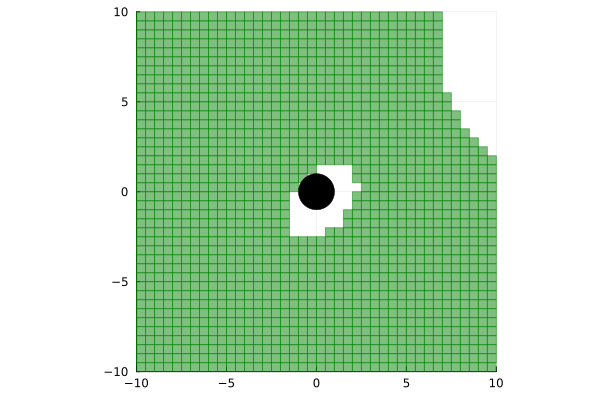

In [13]:
plot_ics_region((-10.0, 10.0), all_barriers; x3_val=2.,x4_val=0)

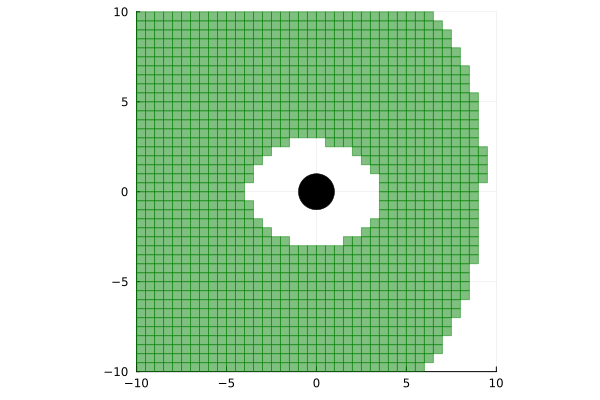

In [14]:
plot_ics_region((-10.0, 10.0), all_barriers; x3_val=-2.,x4_val=0)

[ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_dubins_moving_obstacle.gif


Simulation finished
minimum recentered barrier value = -201.82550679895107
minimum true obstacle distance = 1.7986249379109633
mean tracking error = 4.740559826028677
max tracking error = 8.228499898940978
number of barrier overrides = 244
Animation saved to figures/repulsive_hybrid_dubins_moving_obstacle.gif


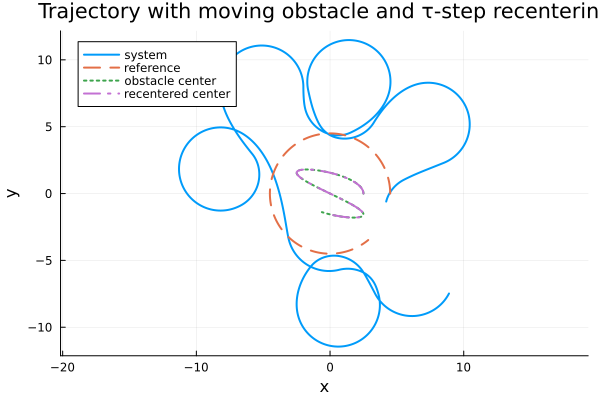

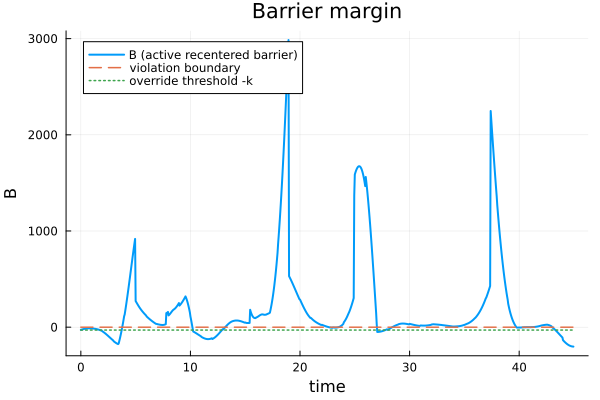

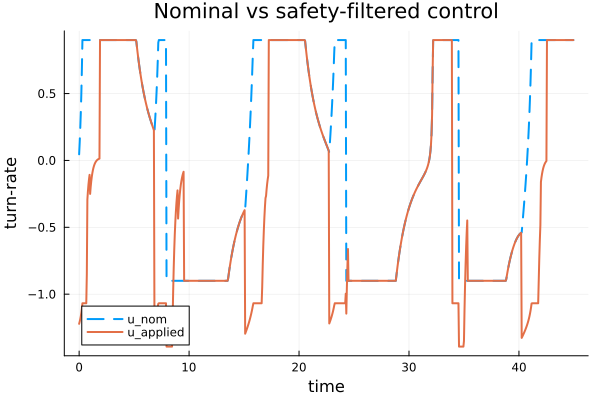

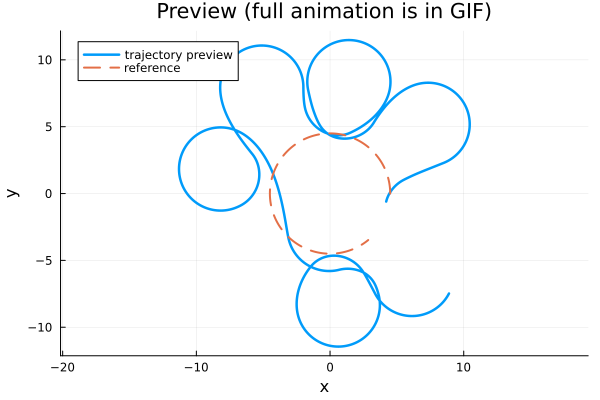

In [15]:
include("repulsive_hybrid_dubins_recenter_sim.jl")
res = run_repulsive_hybrid_dubins_demo(all_barriers; v=2.8, τ_steps=20, dt=0.05, T=45.0, k_override=30.0)
display(res.p_traj); display(res.p_h); display(res.p_u); display(res.anim)